In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [55]:
# Load by file name
R2503_2504 = pd.read_pickle("R2503_2504.pkl")
R2504_2503 = pd.read_pickle("R2504_2503.pkl")
F2504 = pd.read_pickle("2504.pkl")

In [56]:
from pathlib import Path

# 1) Does a directory exist?
base = Path("/home/seismic/AxialFetch/MJ03F-B")
print(base, "→", base.exists(), "(dir)" if base.is_dir() else "(not a dir)")

# 2) Does one specific file exist?
f = base / "MJ03F-B2022DIFF-PRESS-15min.txt"
print(f, "→", f.exists())

# 3) Quick sweep over a pattern
for p in base.glob("MJ03F-B*DIFF-PRESS-15min.txt"):
    print("found:", p.name)


/home/seismic/AxialFetch/MJ03F-B → True (dir)
/home/seismic/AxialFetch/MJ03F-B/MJ03F-B2022DIFF-PRESS-15min.txt → True
found: MJ03F-B2023DIFF-PRESS-15min.txt
found: MJ03F-B2022DIFF-PRESS-15min.txt
found: MJ03F-B2021DIFF-PRESS-15min.txt
found: MJ03F-B2020DIFF-PRESS-15min.txt
found: MJ03F-B2019DIFF-PRESS-15min.txt
found: MJ03F-B2018DIFF-PRESS-15min.txt
found: MJ03F-B2017DIFF-PRESS-15min.txt
found: MJ03F-B2024DIFF-PRESS-15min.txt


Rows in df_pressure: 994


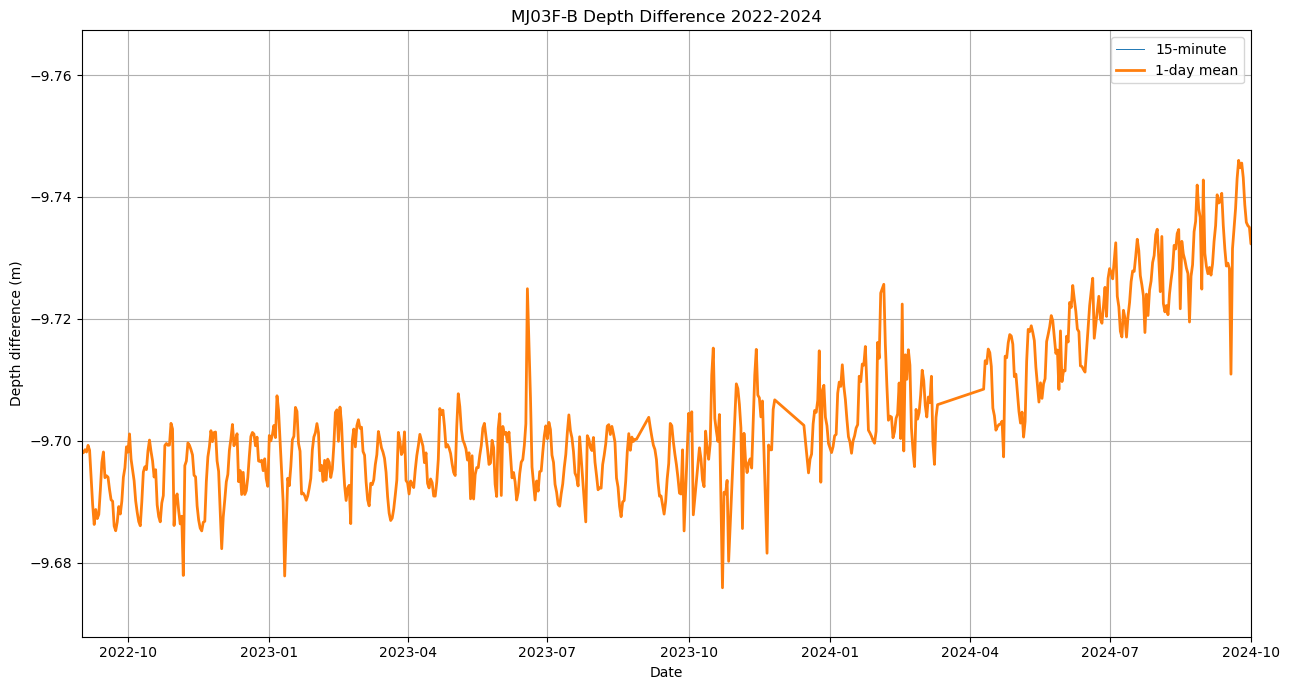

In [57]:
# MJ03F-B depth / pressure processing
# ----------------------------------
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

base_path = Path("/home/seismic/AxialFetch/MJ03F-B")
years     = range(2022, 2025)      # 2022-2024
factor    = 0.67                   # pressure-to-depth conversion

def load_series(years, suffix):
    """Read MJ03F-B DIFF-PRESS files (comma OR whitespace delimited)."""
    frames = []

    for yr in years:
        f = base_path / f"MJ03F-B{yr}DIFF-PRESS-{suffix}.txt"
        if not f.exists():
            continue

        # ---- peek at first line to decide the delimiter -----------------
        with open(f, "r") as fh:
            first_line = fh.readline()

        comma = "," in first_line
        read_opts = dict(
            comment="#",
            engine="python",          # tolerant, handles weird rows
            on_bad_lines="skip"       # silently drop malformed lines
        )

        if comma:
            df = pd.read_csv(f, **read_opts)
            # pick the known columns
            date_col      = df.columns[0]                       # e.g. 'date_1day'
            pressure_col  = (
                "pressure_diff_mean"
                if "pressure_diff_mean" in df.columns
                else df.columns[-1]                             # last numeric col
            )
            df = df[[date_col, pressure_col]]
            df.columns = ["time", "pressure_diff"]
        else:
            # whitespace version: two numeric cols after the date
            df = pd.read_csv(
                f,
                delim_whitespace=True,
                header=None,
                names=["time", "pressure_diff"],
                **read_opts,
            )

        # ---- type conversions & cleanup -------------------------------
        df["time"] = pd.to_datetime(df["time"], format="%Y/%m/%d",
                                    errors="coerce", utc=True)
        df["pressure_diff"] = pd.to_numeric(df["pressure_diff"],
                                            errors="coerce")
        df.dropna(subset=["time", "pressure_diff"], inplace=True)
        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No DIFF-PRESS-{suffix} data found.")
    return pd.concat(frames, ignore_index=True).sort_values("time")

# ----------------------------------------------------------------------
df_15min = load_series(years, "15min")
df_1day  = load_series(years, "1daymeans")

df_15min["depth_m"] = df_15min["pressure_diff"] * factor
df_1day ["depth_m"] = df_1day ["pressure_diff"] * factor

# minimalist (time, pressure) DF
df_pressure = df_1day[["time", "pressure_diff"]]

print("Rows in df_pressure:", len(df_pressure))   # sanity check

# ----------------------------------------------------------------------
# quick plot
plt.figure(figsize=(13, 7))
plt.plot(df_15min["time"], df_15min["depth_m"],
         label="15-minute", linewidth=0.7)
plt.plot(df_1day["time"],  df_1day["depth_m"],
         label="1-day mean", linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("Date")
plt.ylabel("Depth difference (m)")
plt.title("MJ03F-B Depth Difference 2022-2024")
plt.xlim(pd.Timestamp(2022, 9, 1, tz="UTC"),
         pd.Timestamp(2024, 10, 1, tz="UTC"))
#plt.ylim(-14.55, -14.45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [58]:
import pandas as pd

# ------------------------------------------------------------------
# 1) helper → convert any table to a clean UTC-indexed Series
# ------------------------------------------------------------------
def to_series(df, time_col, value_col, fmt=None):
    s = (
        df[[time_col, value_col]]
        .assign(**{time_col: lambda d: pd.to_datetime(
            d[time_col], format=fmt, utc=True)})
        .set_index(time_col)[value_col]
        .astype(float)
        .sort_index()
        .loc[lambda x: ~x.index.duplicated(keep="first")]
    )
    return s

# ------------------------------------------------------------------
# 2) build the master grid from R2503_2504  (distance d1)
# ------------------------------------------------------------------
d1 = to_series(R2503_2504, "Record Time", "Moving Average")

df_var = d1.to_frame("d1")   # index = time, one column so far

# ------------------------------------------------------------------
# 3) prepare the other source series
# ------------------------------------------------------------------
# pressure difference p1 (comes from df_pressure)
p1 = (
    df_pressure.assign(time=pd.to_datetime(df_pressure["time"], utc=True))
               .set_index("time")["pressure_diff"]
               .astype(float)
               .sort_index()
               .loc[lambda x: ~x.index.duplicated(keep="first")]
)

# distance opposite direction d2
d2 = to_series(R2504_2503, "Record Time", "Moving Average")

# corrected pressure p2
p2 = to_series(F2504, "DateTime", "Corrected Pressure (kPa)")

In [59]:
# ------------------------------------------------------------------
# 4) interpolate everything onto the master grid
# ------------------------------------------------------------------
def onto_master(source, master_index):
    union = source.reindex(master_index.union(source.index))
    filled = union.interpolate("time")
    return filled.reindex(master_index)

df_var["p1"] = onto_master(p1, df_var.index)
df_var["d2"] = onto_master(d2, df_var.index)
df_var["p2"] = onto_master(p2, df_var.index)

# optional order
df_var = df_var[["p1", "p2", "d1", "d2"]]

# reset index so 'time' is a normal column
df_var = df_var.reset_index().rename(columns={"index": "time"})


In [60]:
df_var = df_var.dropna().reset_index(drop=True)

import pandas as pd

cutoff = pd.Timestamp(2022, 9, 7, tz="UTC")

# ensure 'time' is datetime and remove earlier rows
df_var["Record Time"] = pd.to_datetime(df_var["Record Time"], utc=True)
df_var = df_var[df_var["Record Time"] >= cutoff].reset_index(drop=True)


In [61]:
df_var

,Record Time,p1,p2,d1,d2
0,2022-09-07 00:30:00+00:00,-14.468472,15562.294524,176562.898512,176563.317026
1,2022-09-07 04:30:00+00:00,-14.467363,15562.203899,176562.990556,176563.288077
2,2022-09-07 08:30:00+00:00,-14.466255,15562.083265,176562.767574,176563.186840
3,2022-09-07 12:30:00+00:00,-14.465146,15561.931240,176562.427527,176563.192236
4,2022-09-07 16:30:00+00:00,-14.464037,15561.968291,176562.394427,176563.197631
...,...,...,...,...,...
4346,2024-09-04 04:30:00+00:00,-14.519708,15560.114308,176562.927257,176562.287512
4347,2024-09-04 08:30:00+00:00,-14.519395,15560.299788,176562.951289,176562.319780
4348,2024-09-04 12:30:00+00:00,-14.519082,15560.229376,176562.956069,176562.318533
4349,2024-09-04 16:30:00+00:00,-14.518769,15560.194736,176562.848136,176562.212994


Text(0.5, 1.0, 'Central - West Distance')

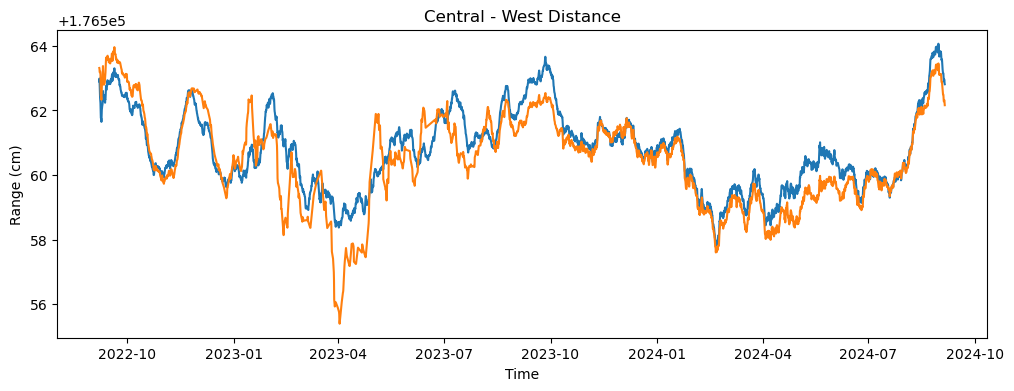

In [62]:
plt.figure(figsize=(12, 4))
plt.plot(df_var['Record Time'],df_var['d1'])
plt.plot(df_var['Record Time'],df_var['d2'])
plt.xlabel("Time")
plt.ylabel("Range (cm)")
plt.title("Central - West Distance")

0       1765.628985
1       1765.629906
2       1765.627676
3       1765.624275
4       1765.623944
           ...     
4346    1765.629273
4347    1765.629513
4348    1765.629561
4349    1765.628481
4350    1765.628134
Name: d1, Length: 4351, dtype: float64

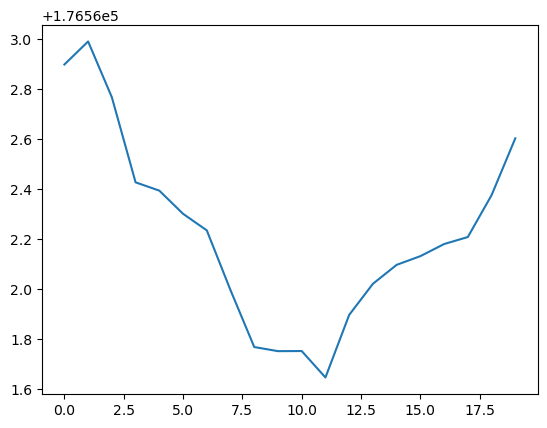

In [79]:
plt.plot(df_var['d1'][0:20])
df_var['d1']/100

In [81]:
1765.61752817-1765.628134

-0.010605830000031347

In [63]:
import numpy as np

#-------------------------------------------------
# 1) EXTRACT ARRAYS
#-------------------------------------------------
time = df_var['Record Time'].values          # datetime64
p1   = df_var['p1'].values                   # differential pressure (ΔP)
p2   = df_var['p2'].values                   # absolute pressure (P)
r_WC = df_var['d1'].values                   # range W → C
r_CW = df_var['d2'].values                   # range C → W

#-------------------------------------------------
# 2) TIME  →  FLOAT DAYS
#-------------------------------------------------
t_days = (time - time[0]) / np.timedelta64(1, 'D')

#-------------------------------------------------
# 3) PERIODIC TERMS
#-------------------------------------------------
T_year = 365.25
ω      = 2.0 * np.pi / T_year
sin_t  = np.sin(ω * t_days)
cos_t  = np.cos(ω * t_days)

#-------------------------------------------------
# 4) STANDARDISE PRESSURES
#-------------------------------------------------
p1_std = (p1 - p1.mean()) / p1.std()
p2_std = (p2 - p2.mean()) / p2.std()

#-------------------------------------------------
# 5) DESIGN MATRIX  (N × 5)  with intercept
#     R(t) = C + a·p1_std + b·p2_std + c·sin + d·cos
#-------------------------------------------------
A = np.column_stack([np.ones_like(p1), p1_std, p2_std, sin_t, cos_t])

#-------------------------------------------------
# 6) LEAST-SQUARES FITS
#-------------------------------------------------
x_WC, *_ = np.linalg.lstsq(A, r_WC, rcond=None)   # (C, a, b, c, d)  for W→C
x_CW, *_ = np.linalg.lstsq(A, r_CW, rcond=None)   # (C, a, b, c, d)  for C→W

r_WC_fit = A @ x_WC
r_CW_fit = A @ x_CW

#-------------------------------------------------
# 7) RESULTS
#-------------------------------------------------
print("==== Range W→C coefficients ====")
print(f"C_WC (intercept) : {x_WC[0]:.6f}")
print(f"a_WC (ΔP std)    : {x_WC[1]:.6f}")
print(f"b_WC (P  std)    : {x_WC[2]:.6f}")
print(f"c_WC (annual sin): {x_WC[3]:.6f}")
print(f"d_WC (annual cos): {x_WC[4]:.6f}")

print("\n==== Range C→W coefficients ====")
print(f"C_CW (intercept) : {x_CW[0]:.6f}")
print(f"a_CW (ΔP std)    : {x_CW[1]:.6f}")
print(f"b_CW (P  std)    : {x_CW[2]:.6f}")
print(f"c_CW (annual sin): {x_CW[3]:.6f}")
print(f"d_CW (annual cos): {x_CW[4]:.6f}")


==== Range W→C coefficients ====
C_WC (intercept) : 176560.765699
a_WC (ΔP std)    : 0.101051
b_WC (P  std)    : 0.057612
c_WC (annual sin): 0.282844
d_WC (annual cos): 1.202316

==== Range C→W coefficients ====
C_CW (intercept) : 176560.458700
a_CW (ΔP std)    : 0.085992
b_CW (P  std)    : 0.053609
c_CW (annual sin): 0.546941
d_CW (annual cos): 1.438316


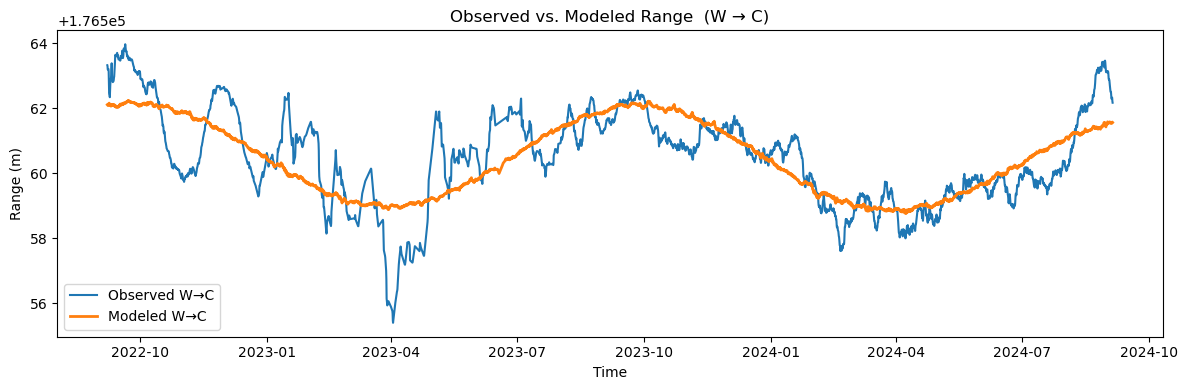

In [64]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 6)  OBSERVED vs. MODELED  –  RANGE W→C  (r_CE)
# ------------------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(df_var['Record Time'], r_CW,      label='Observed W→C')
plt.plot(df_var['Record Time'], r_CW_fit,  label='Modeled W→C', linewidth=2)
plt.xlabel("Time")
plt.ylabel("Range (m)")
plt.title("Observed vs. Modeled Range  (W → C)")
plt.legend()
plt.tight_layout()
plt.show()

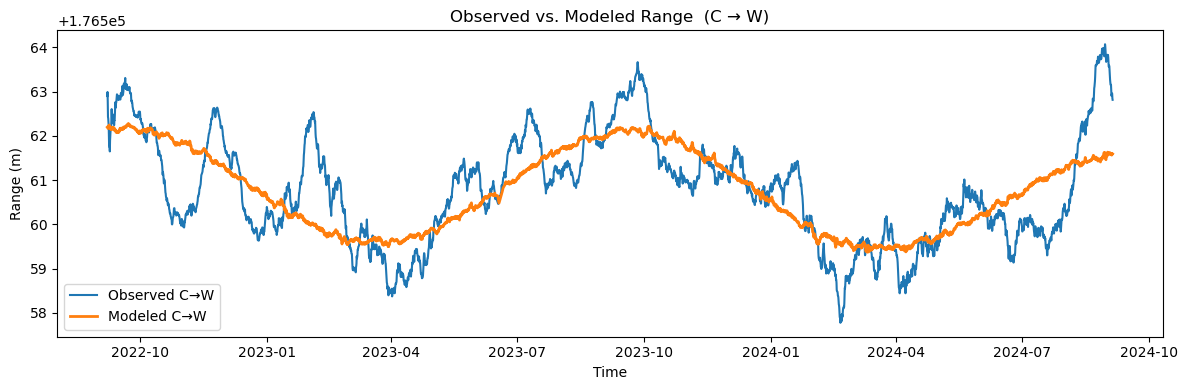

In [65]:
# ------------------------------------------------------------------
# 7)  OBSERVED vs. MODELED  –  RANGE C→W  (r_EC)
# ------------------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(df_var['Record Time'], r_WC,      label='Observed C→W')
plt.plot(df_var['Record Time'], r_WC_fit,  label='Modeled C→W', linewidth=2)
plt.xlabel("Time")
plt.ylabel("Range (m)")
plt.title("Observed vs. Modeled Range  (C → W)")
plt.legend()
plt.tight_layout()
plt.show()

In [66]:

print('R² (W→C) =', r2_score(r_WC,  r_WC_fit))
print('R² (C→W) =', r2_score(r_CW,  r_CW_fit))


R² (W→C) = 0.5489567075552478
R² (C→W) = 0.5770614270016604


In [67]:
import numpy as np

#-------------------------------------------------
# 1) EXTRACT ARRAYS
#-------------------------------------------------
time = df_var['Record Time'].values         # datetime64
p1   = df_var['p1'].values                  # differential pressure (ΔP)
r_WC = df_var['d1'].values                  # range W → C
r_CW = df_var['d2'].values                  # range C → W

#-------------------------------------------------
# 2) TIME  →  FLOAT DAYS
#-------------------------------------------------
t_days = (time - time[0]) / np.timedelta64(1, 'D')

#-------------------------------------------------
# 3) PERIODIC TERMS
#-------------------------------------------------
T_year = 365.25
ω      = 2.0 * np.pi / T_year
sin_t  = np.sin(ω * t_days)
cos_t  = np.cos(ω * t_days)

#-------------------------------------------------
# 4) STANDARDISE ΔP
#-------------------------------------------------
p1_std = (p1 - p1.mean()) / p1.std()

#-------------------------------------------------
# 5) DESIGN MATRIX  (N × 4)   with intercept, NO absolute pressure
#     R(t) = C + a·p1_std + b·sin + c·cos
#-------------------------------------------------
A = np.column_stack([np.ones_like(p1), p1_std, sin_t, cos_t])

#-------------------------------------------------
# 6) LEAST-SQUARES FITS
#-------------------------------------------------
x_WC, *_ = np.linalg.lstsq(A, r_WC, rcond=None)   # (C, a, b, c)  for W→C
x_CW, *_ = np.linalg.lstsq(A, r_CW, rcond=None)   # (C, a, b, c)  for C→W

r_WC_fit = A @ x_WC
r_CW_fit = A @ x_CW

#-------------------------------------------------
# 7) RESULTS
#-------------------------------------------------
print("==== Range W→C coefficients ====")
print(f"C_WC (intercept) : {x_WC[0]:.6f}")
print(f"a_WC (ΔP std)    : {x_WC[1]:.6f}")
print(f"b_WC (annual sin): {x_WC[2]:.6f}")
print(f"c_WC (annual cos): {x_WC[3]:.6f}")

print("\n==== Range C→W coefficients ====")
print(f"C_CW (intercept) : {x_CW[0]:.6f}")
print(f"a_CW (ΔP std)    : {x_CW[1]:.6f}")
print(f"b_CW (annual sin): {x_CW[2]:.6f}")
print(f"c_CW (annual cos): {x_CW[3]:.6f}")


==== Range W→C coefficients ====
C_WC (intercept) : 176560.765735
a_WC (ΔP std)    : 0.138950
b_WC (annual sin): 0.283093
c_WC (annual cos): 1.223992

==== Range C→W coefficients ====
C_CW (intercept) : 176560.458733
a_CW (ΔP std)    : 0.121258
b_CW (annual sin): 0.547172
c_CW (annual cos): 1.458486


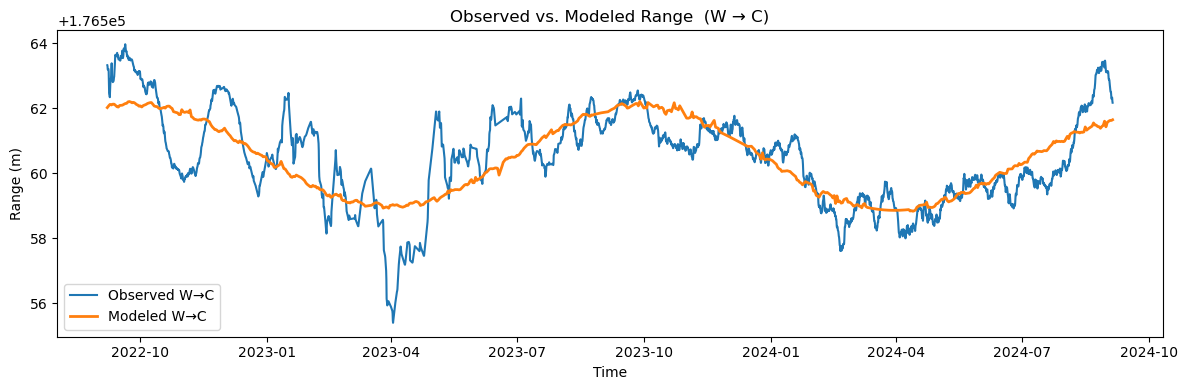

In [68]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 6)  OBSERVED vs. MODELED  –  RANGE W→C  (r_CE)
# ------------------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(df_var['Record Time'], r_CW,      label='Observed W→C')
plt.plot(df_var['Record Time'], r_CW_fit,  label='Modeled W→C', linewidth=2)
plt.xlabel("Time")
plt.ylabel("Range (m)")
plt.title("Observed vs. Modeled Range  (W → C)")
plt.legend()
plt.tight_layout()
plt.show()

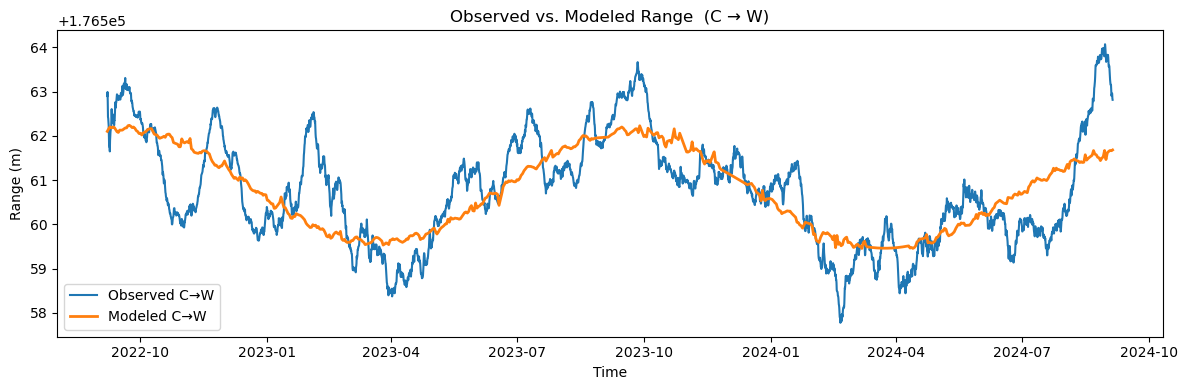

In [69]:
# ------------------------------------------------------------------
# 7)  OBSERVED vs. MODELED  –  RANGE C→W  (r_EC)
# ------------------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(df_var['Record Time'], r_WC,      label='Observed C→W')
plt.plot(df_var['Record Time'], r_WC_fit,  label='Modeled C→W', linewidth=2)
plt.xlabel("Time")
plt.ylabel("Range (m)")
plt.title("Observed vs. Modeled Range  (C → W)")
plt.legend()
plt.tight_layout()
plt.show()

In [70]:

print('R² (W→C) =', r2_score(r_WC,  r_WC_fit))
print('R² (C→W) =', r2_score(r_CW,  r_CW_fit))


R² (W→C) = 0.547803671732086
R² (C→W) = 0.5763755207033137
